In [1]:
import pandas as pd
import numpy as np
import os
import torch
import seaborn as sns
import random

from scipy.stats import pearsonr, spearmanr
from scipy.stats import rankdata
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc


from Bio import pairwise2
from Bio.Seq import Seq
from Bio.Align import substitution_matrices
from Bio import SeqIO

from random import sample

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    positions,
    num_muts_column_name,
    DATASET_PATHS
)


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
across_datasets_results = {}

In [3]:

def get_relevant_columns_gfp_protgym(df, first_col, last_col):
    si = np.where(df.columns == first_col)[0][0]
    ei = np.where(df.columns == last_col)[0][0]+1
    return df.columns[si:ei]

def nmt_relevant_columns(df):
    si = np.where(df.columns == "1")[0][0]
    ei = np.where(df.columns == "272")[0][0]+1
    positions_with_mutations =  np.array([len(pd.unique(df.iloc[:,i])) > 1 for i in range(si,ei)])
    return df.columns[si:ei][positions_with_mutations]

def get_relevant_columns(dataset, df):
    cols = get_relevant_columns_gfp_protgym(df, positions[dataset][0], positions[dataset][1])
    return cols

def get_num_muts_column_name(dataset):
    return {
        "pard3": "num_muts",
        "lov": "num_muts",
        "gfp": "num_muts",
        "pte": "num_muts",
        "gcn4": "num_muts",
        "nmt": "num_muts"
    }[dataset]

# --- OHE Feature Creation ---
def get_one_hot_encoding(sdf, relevant_columns):
    one_hot_encoding = pd.get_dummies(sdf[relevant_columns])
    return one_hot_encoding

datasets_and_activity = {
    "gcn4": {"path": "./data/gcn4/gcn4.csv", "activity_col": "activity"},
    "pard3": {"path": "./data/pard3/pard3.csv", "activity_col": "activity"},
    "pte": {"path": "./data/pte/pte.csv", "activity_col": "p-nitrophenyl_octanoate"},
    "nmt": {"path": "./data/nmt/nmt_full_seq.csv", "activity_col": "activity"},
    "lov": {"path": "./data/lov/lov.csv", "activity_col": "activity"},
    "gfp": {"path": "./data/gfp/gfp_dataset_10mut.csv", "activity_col": "inactive"},
    "aamyl": {"path": "./data/aamyl/aamyl.csv", "activity_col": "activity"}
}



def get_best_worst_ranks(best, worst):
    """
    Given arrays or lists of best and worst scores,
    returns (ranks_best, ranks_worst) where each contains
    the rank (1 = highest) of each input element.
    """
    all_scores = np.array(list(best) + list(worst))
    # Higher score = higher rank, so negate for ranking function
    ranks = rankdata(-all_scores, method='average')
    ranks_best = ranks[:len(best)]
    ranks_worst = ranks[len(best):]
    return ranks_best, ranks_worst


import sys
os.chdir(os.path.join(os.getcwd(), "../code/"))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from plm_base import *
plm_init(os.path.join(os.getcwd(), "../"))

os.chdir(os.path.join(os.getcwd(), "../notebooks"))


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def get_one_hot_encoding(sdf, relevant_columns):
    one_hot_encoding = pd.get_dummies(sdf[relevant_columns])
    return one_hot_encoding


sample_settings = {

    "gcn4": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5,10,20,50,100]
    },
    "pard3": {
        "space_sizes": [3,4,5,6,7,8,9,10,20],
        "k_values": [5,10,20,50,100],
    },
    "aamyl": {
        "space_sizes": [3,4,5,6,7,8,9,10,20],
        "k_values": [5,10,20,50,100]
    },
    "gfp": {
        "space_sizes": [3,4,5,6,7,8],
        "k_values": [5, 10, 50, 100, 200]
    },
    "lov": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5, 10, 50, 100, 200, 500]
    },
    "nmt": {
        "space_sizes": [3,4,5,6,7,8,9,10,20,25],
        "k_values": [4, 5, 8, 10, 15, 20, 30, 40, 50]
    },
    "pte": {
        "space_sizes": [2,3,4],
        "k_values": [4, 5, 8, 10, 15, 20]
    }
}

In [5]:

def calc_pssm_matrices(
    pssm_score_per_mutation,
    actual_pos_per_ohe_col,
    activity,
    ohe,
    space_sizes,
    k_values,
    percentile=90,
    unique_mutations=False,
):
    # Rank mutations by PSSM score (descending)
    pssm_rank = np.argsort(-pssm_score_per_mutation)

    upper_percentile = np.percentile(activity, 90)
    gof_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=int)
    mean_activity_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)
    median_activity_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)

    for s_idx, s in enumerate(space_sizes):
        # Find indices of top N+1 unique mutations by PSSM score

        if unique_mutations:
            pssm_first_unique_indices = []
            seen = set()
            arr = np.array(actual_pos_per_ohe_col)[pssm_rank]
            for idx, val in enumerate(arr):
                if val not in seen:
                    pssm_first_unique_indices.append(idx)
                    seen.add(val)
                if len(pssm_first_unique_indices) == s + 1:
                    break
            chosen_mutations_pssm = pssm_rank[pssm_first_unique_indices]
        else:
            chosen_mutations_pssm = pssm_rank[:s+1]

        # Select N unique mutation columns, score each sequence by sum of their OHE columns
        closest_to_pssm_space = np.argsort(
            -ohe[:, chosen_mutations_pssm].sum(axis=1)
        )

        # For each top-K
        for k_idx, k in enumerate(k_values):
            activities_pssm = activity[closest_to_pssm_space[:k]]
            # Number of GOF (above upper 90th percentile)
            num_of_gof = np.sum(activities_pssm > upper_percentile)
            # Mean activity
            mean_activity = np.mean(activities_pssm)
            median_activity = np.median(activities_pssm)

            gof_matrix[s_idx, k_idx] = num_of_gof
            mean_activity_matrix[s_idx, k_idx] = mean_activity
            median_activity_matrix[s_idx, k_idx] = median_activity

    return gof_matrix, mean_activity_matrix, median_activity_matrix

def get_top_worst_K_mutations_empirical(
    ohe,
    activity,
    K=5,
    plot=False
):
    mean_with_mutation_per_column = []
    mean_without_mutation_per_column = []
    for i in range(ohe.shape[1]):
        mean_val_with_mutation = np.mean(activity[np.where(ohe[:, i] == 1)[0]])
        mean_val_without_mutation = np.mean(activity[np.where(ohe[:, i] == 0)[0]])
        mean_with_mutation_per_column.append(mean_val_with_mutation/mean_val_without_mutation)
        mean_without_mutation_per_column.append(mean_val_without_mutation/mean_val_with_mutation)


    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(6,3))

        axes[0].scatter(mean_without_mutation_per_column, mean_with_mutation_per_column)
        axes[0].set_xlabel("Mean without mutation")
        axes[0].set_ylabel("Mean with mutation")
        axes[0].set_title("With vs Without Mutation")

        ratio = np.array(mean_with_mutation_per_column) / np.array(mean_without_mutation_per_column)
        axes[1].hist(ratio, bins=20)
        axes[1].set_xlabel("With / Without Mutation Ratio")
        axes[1].set_ylabel("Frequency")
        axes[1].set_title("Distribution of Ratio")

        plt.tight_layout()
        plt.show()

    ratio = np.array(mean_with_mutation_per_column)/np.array(mean_without_mutation_per_column)
    worst_K_indices = np.argsort(ratio)[0:K]
    best_K_indices  = np.argsort(-ratio)[0:K]

    return (best_K_indices, worst_K_indices, ratio)


def run_model(
    pssm,
    ohe,
    ohe_columns,
    activity,
    vocab_col_idx_dict,
    k_values,
    space_sizes
):    

    best_K_empirical_indices, worst_K_empirical_indices, ratio = get_top_worst_K_mutations_empirical(
        ohe,
        activity,
        K=5,
        plot=True
    )

    best_K_empirical_mutations = ohe_columns[best_K_empirical_indices]
    worst_K_empirical_mutations = ohe_columns[worst_K_empirical_indices]

    actual_pos_per_ohe_col = [int(col.split("_")[0][1:]) for col in ohe_columns] # PDB INDEX
    actual_vocab_per_ohe_col = [col.split("_")[-1] for col in ohe_columns] 
    pssm_score_per_mutation = []

    for p,v in zip(actual_pos_per_ohe_col, actual_vocab_per_ohe_col):
        col_idx = vocab_col_idx_dict[v]
        row_idx = p - 1 # IT SHOULD BE PDB IDX!!!!!!!!!!!
        pssm_score_per_mutation.append(pssm[row_idx,col_idx])

    pssm_score_per_mutation = np.array(pssm_score_per_mutation)

    pssm_scores_best = pssm_score_per_mutation[best_K_empirical_indices]
    pssm_scores_worst = pssm_score_per_mutation[worst_K_empirical_indices]

    # PSSM ranks
    ranks_best, ranks_worst = get_best_worst_ranks(
        pssm_scores_best, 
        pssm_scores_worst
    )

    unique_gof_matrix, unique_mean_activity_matrix, unique_median_activity_matrix=  calc_pssm_matrices(
        pssm_score_per_mutation,
        actual_pos_per_ohe_col,
        activity,
        ohe,
        k_values=k_values,
        space_sizes=space_sizes,
        unique_mutations=True
    )

    non_unique_gof_matrix, non_unique_mean_activity_matrix, non_unique_median_activity_matrix=  calc_pssm_matrices(
        pssm_score_per_mutation,
        actual_pos_per_ohe_col,
        activity,
        ohe,
        k_values=k_values,
        space_sizes=space_sizes,
        unique_mutations=False
    )

    empirical_vs_model_prob_spearmanr = spearmanr(ratio, pssm_score_per_mutation)

    results = {
        "empirical_vs_model_prob_spearmanr": empirical_vs_model_prob_spearmanr,
        "unique_gof_matrix": unique_gof_matrix,
        "unique_mean_activity_matrix": unique_mean_activity_matrix,
        "unique_median_activity_matrix": unique_median_activity_matrix,
        "non_unique_gof_matrix": non_unique_gof_matrix,
        "non_unique_mean_activity_matrix": non_unique_mean_activity_matrix,
        "non_unique_median_activity_matrix": non_unique_median_activity_matrix,
        "ranks_best": ranks_best,
        "ranks_worst": ranks_worst,
        "empirical_vs_model_prob_spearmanr": empirical_vs_model_prob_spearmanr,
    }

    return results


In [ ]:
all_models = [
    "esm2_t6_8M_UR50D", 
    "esm2_t12_35M_UR50D", 
    "esm2_t30_150M_UR50D", 
    "esm2_t33_650M_UR50D"
]

all_results = {}

for model_name in all_models:

    model = plmEmbeddingModel(
        plm_name="%s" % model_name, 
        logits_only=True, 
        emb_only=False
    ).eval()
            
    for dataset in ["aamyl"]:#["gfp","pard3", "pte", "gcn4", "nmt", "lov"]:    
        dataset_path = DATASET_PATHS[dataset]
        df = pd.read_csv(dataset_path)
        wt_seq = df[df["num_muts"] == 0]["full_seq"].iloc[0]

        k_values = sample_settings[dataset]["k_values"]
        space_sizes = sample_settings[dataset]["space_sizes"]

        # get one-hot encoding for relevant columns
        relevant_columns = get_relevant_columns(dataset, df)
        ohe = get_one_hot_encoding(df, relevant_columns)
        ohe_columns = ohe.columns
        ohe = ohe.to_numpy().astype(int)
        assert ohe.shape[1] == sum([len(pd.unique(df[C])) for C in relevant_columns])

        activity_col = datasets_and_activity[dataset]["activity_col"]
        activity = df[activity_col].to_numpy()

        if dataset == "gfp":
            activity = (~activity).astype(int)

        pssm = pd.read_csv(f"./data/{dataset}//pssm_scores.csv")
        vocab_col_idx_dict = dict((v,i) for i,v in enumerate(pssm.columns[1:]))

        np_pssm = pssm.iloc[:,1:].to_numpy()

        pssm_results = run_model(
            np_pssm, 
            ohe,
            ohe_columns,
            activity,
            vocab_col_idx_dict,
            k_values,
            space_sizes
        )

        pssm_results["actual_pssm"] = pssm
        pssm_results["actual_np_pssm"] = np_pssm

        res_name = "%s_%s" % (dataset, "pssm")

        if res_name not in all_results:
            all_results[res_name] = pssm_results

        vocab = model.vocab
        all_tokens = model.encode("".join(vocab))
        wt_tokens = model.encode(wt_seq)
        all_tokens = all_tokens[1:-1]

        logits_path = f"./data/{dataset}/%s_logits.np.npy" % model_name
        if os.path.exists(logits_path):
            logits = np.load(logits_path)
        else:
            logits = model(torch.tensor(wt_tokens).unsqueeze(0))
            logits = logits[0].softmax(dim=1)
            logits = logits.detach().numpy()
            np.save(logits_path, logits)

        model_logits = logits[1:-1,:] # Get rid

        rearranged_to_pssm_logits = []
        for vc in pssm.columns[1:]:
            rearranged_to_pssm_logits.append(model_logits[:,np.where(np.array(vocab) == vc)[0]])

        model_like_pssm = np.concatenate(rearranged_to_pssm_logits, axis=1) 
        assert np_pssm.shape == model_like_pssm.shape

        plm_results = run_model(
            model_like_pssm, 
            ohe,
            ohe_columns,
            activity,
            vocab_col_idx_dict,
            k_values,
            space_sizes
        )

        plm_results["actual_pssm"] = model_logits
        plm_results["actual_np_pssm"] = model_like_pssm

        res_name = "%s_%s" % (dataset, model_name)
        all_results[res_name] = plm_results

        

        print("Finsihed analyzing %s - %s" % (dataset, model_name))





In [17]:
metrics = ["gof", "mean_activity", "median_activity"
]
df_all = []
mut_ranks_all = []
all_results.keys()

for key in all_results.keys():
    dataset_model_analysis = all_results[key]
    dataset = key.split("_")[0]
    model = "_".join(key.split("_")[1:])
    k_values = sample_settings[dataset]["k_values"]
    space_sizes = sample_settings[dataset]["space_sizes"]

    mut_ranks_all.append({
        "empirical_vs_model_prob_spearmanr": dataset_model_analysis["empirical_vs_model_prob_spearmanr"].statistic,
        "ranks_best": dataset_model_analysis["ranks_best"].mean(),
        "ranks_worst": dataset_model_analysis["ranks_worst"].mean(),
        "dataset": dataset,
        "model": model,
    })

    for unique in [True, False]:
        for metric in metrics:

            metric_name = "%s_%s_matrix" % ("unique" if unique else "non_unique", metric)
            results_matrix = dataset_model_analysis[metric_name]
            results_df = pd.DataFrame(results_matrix, index=space_sizes, columns=k_values)
            melted_results = results_df.reset_index().melt(id_vars='index', var_name='k_value', value_name="value")
            melted_results = melted_results.rename(columns={'index': 'space_size'})
            melted_results["dataset"] = dataset
            melted_results["model"] = model
            melted_results["unique"] = unique
            melted_results["metric"] = metric
            df_all.append(melted_results)

    # non_unique_gof_matrix = dataset_model_analysis["non_unique_gof_matrix"]
    # unique_mean_activity_matrix = dataset_model_analysis["unique_mean_activity_matrix"]
    # non_unique_mean_activity_matrix = dataset_model_analysis["non_unique_mean_activity_matrix"]
    # unique_median_activity_matrix = dataset_model_analysis["unique_median_activity_matrix"]
    # non_unique_median_activity_matrix = dataset_model_analysis["non_unique_median_activity_matrix"]
    
    #break

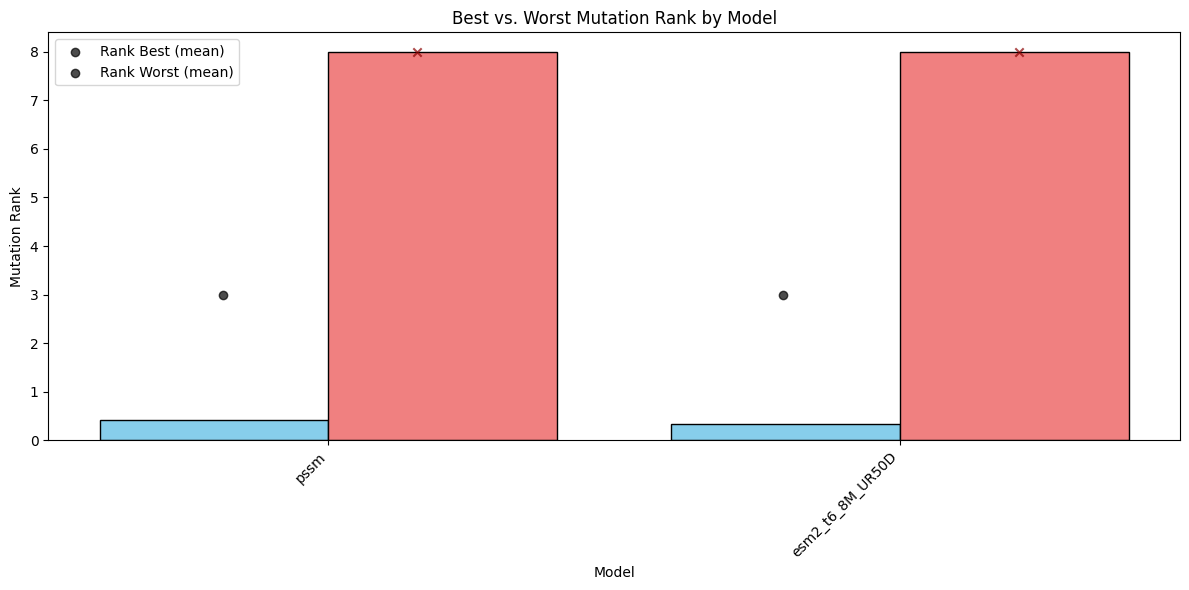

In [23]:
mut_ranks_all = pd.DataFrame(mut_ranks_all)

plt.figure(figsize=(12, 6))

bar_width = 0.4
x_order = mut_ranks_all["model"].unique()
x = np.arange(len(x_order))

# Compute offset for jitter
offset = bar_width / 2 * 0.85  # leave a little gap from the bar center

means_best = mut_ranks_all.groupby("model")["empirical_vs_model_prob_spearmanr"].mean().reindex(x_order)
means_worst = mut_ranks_all.groupby("model")["ranks_worst"].mean().reindex(x_order)

# Barplot: side by side for ranks_best and ranks_worst
plt.bar(x - bar_width/2, means_best, width=bar_width, color="skyblue", edgecolor="black", label="Rank Best")
plt.bar(x + bar_width/2, means_worst, width=bar_width, color="lightcoral", edgecolor="black", label="Rank Worst")

# We'll overlay the stripplots so the points are visually aligned to the bars
# Instead of default x-categorical, pass x as positions (numeric)

# For ranks_best
for i, model in enumerate(x_order):
    this_y = mut_ranks_all.loc[mut_ranks_all["model"] == model, "ranks_best"].values
    plt.scatter(
        np.full_like(this_y, x[i] - offset, dtype=float) +
        np.random.uniform(-0.04, 0.04, size=len(this_y)), # jitter
        this_y,
        color="black",
        alpha=0.7,
        marker="o",
        zorder=4
    )

# For ranks_worst
for i, model in enumerate(x_order):
    this_y = mut_ranks_all.loc[mut_ranks_all["model"] == model, "ranks_worst"].values
    plt.scatter(
        np.full_like(this_y, x[i] + offset, dtype=float) +
        np.random.uniform(-0.04, 0.04, size=len(this_y)), # jitter
        this_y,
        color="darkred",
        alpha=0.7,
        marker="x",
        zorder=4
    )

plt.xlabel("Model")
plt.ylabel("Mutation Rank")
plt.title("Best vs. Worst Mutation Rank by Model")
plt.xticks(ticks=x, labels=x_order, rotation=45, ha="right")
plt.legend(["Rank Best (mean)", "Rank Worst (mean)"])
plt.tight_layout()
plt.show()


/tmp/ipykernel_804244/819980605.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df["dataset_model"] = subset_df["dataset"] + " / " + subset_df["model"]
/tmp/ipykernel_804244/819980605.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df["dataset_model"] = pd.Categorical(subset_df["dataset_model"], categories=ordered_dataset_models, ordered=True)


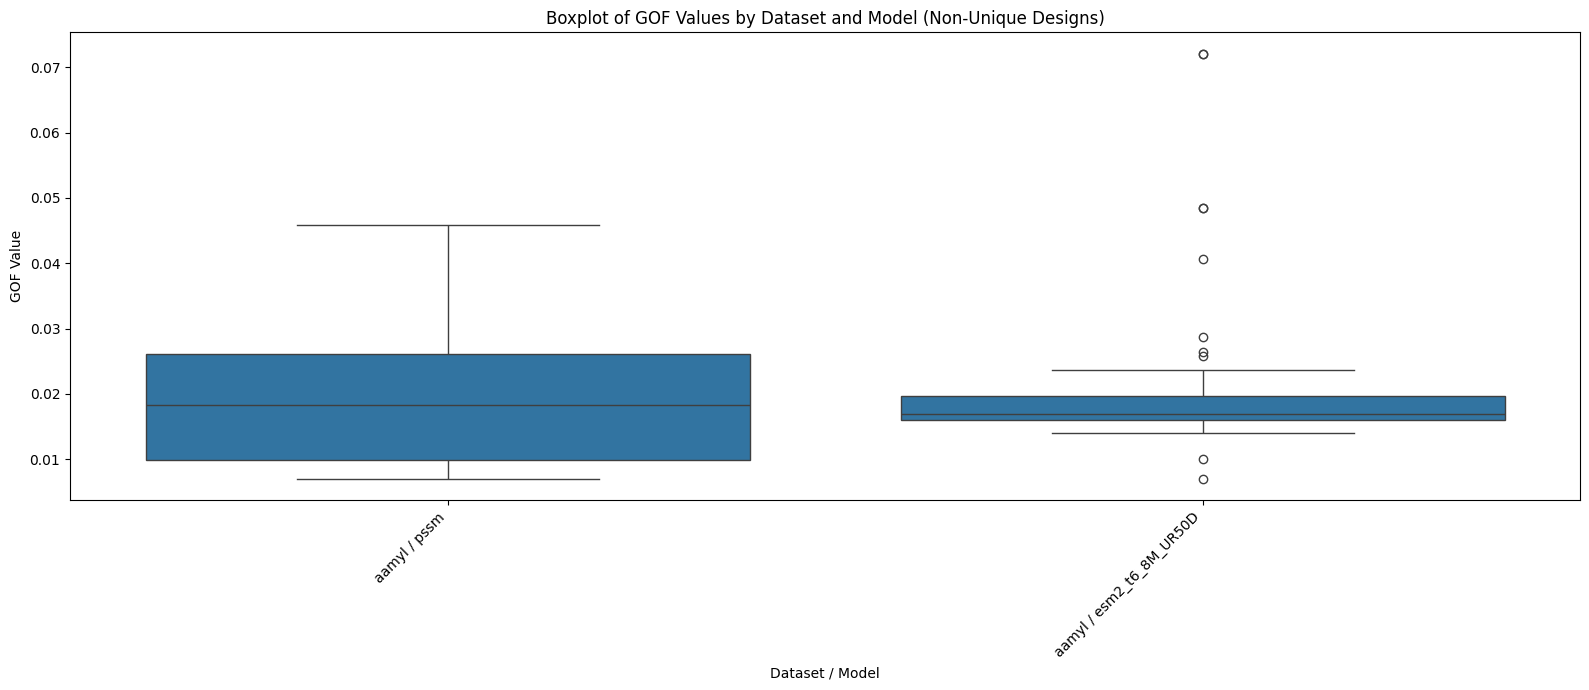

In [20]:
results_df = pd.concat(df_all)
results_df.columns

import seaborn as sns
import matplotlib.pyplot as plt

# Subset results_df for metric == "gof" and unique == False
subset_df = results_df[(results_df["metric"] == "median_activity") & (results_df["unique"] == False)]

# Create a new column that combines dataset and model for grouped boxplots
subset_df["dataset_model"] = subset_df["dataset"] + " / " + subset_df["model"]

# Define desired dataset order
dataset_order = ["aamyl"]

# Get all model names in original dataframe, in the order they first appear per dataset
models_per_dataset = {ds: subset_df[subset_df["dataset"] == ds]["model"].unique() for ds in dataset_order}

# Create the ordered x-axis: for each dataset, append its model combinations in order
ordered_dataset_models = []
for ds in dataset_order:
    for model in models_per_dataset[ds]:
        ordered_dataset_models.append(f"{ds} / {model}")

# Make the new column categorical with our ordering
subset_df["dataset_model"] = pd.Categorical(subset_df["dataset_model"], categories=ordered_dataset_models, ordered=True)

plt.figure(figsize=(16, 7))
sns.boxplot(
    x="dataset_model",
    y="value",
    data=subset_df,
    order=ordered_dataset_models
)
plt.xlabel("Dataset / Model")
plt.ylabel("GOF Value")
plt.title("Boxplot of GOF Values by Dataset and Model (Non-Unique Designs)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/tmp/ipykernel_804244/576736261.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


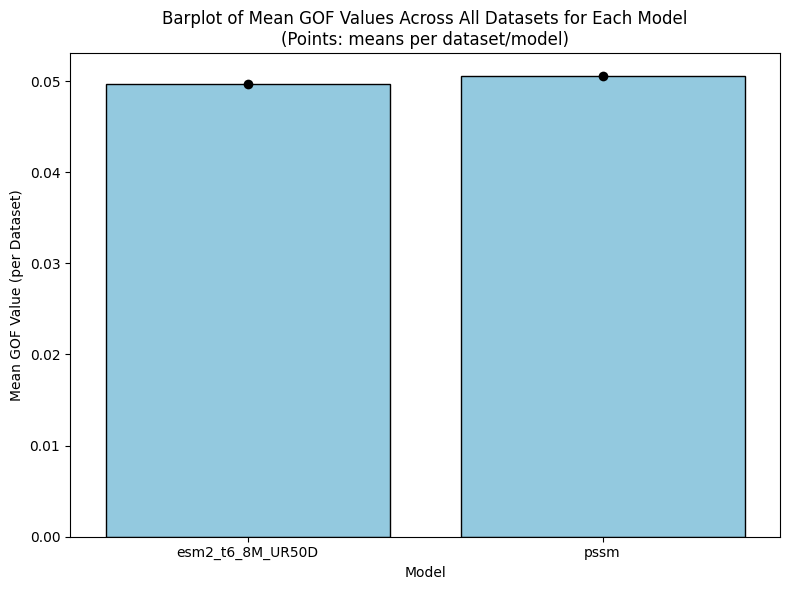

One-way ANOVA across model (ignoring dataset):
F-statistic: 0.299, p-value: 5.858e-01
statsmodels not installed, skipping two-way ANOVA.


In [21]:
results_df = pd.concat(df_all)

import seaborn as sns
import matplotlib.pyplot as plt

# Subset results_df for metric == "gof" and unique == False
subset_df = results_df[(results_df["metric"] == "mean_activity") & (results_df["unique"] == True)]

# For each (dataset, model), compute the mean value
mean_df = (
    subset_df
    .groupby(["dataset", "model"])["value"]
    .median()
    .reset_index()
)

plt.figure(figsize=(8, 6))
# Barplot of mean value for each model (averaged over datasets)
sns.barplot(
    x="model",
    y="value",
    data=mean_df,
    order=mean_df["model"].unique(),
    ci=None,
    color="skyblue",
    edgecolor="black"
)

# Overlay actual mean points as scatter
sns.stripplot(
    x="model",
    y="value",
    data=mean_df,
    order=mean_df["model"].unique(),
    color='black',
    size=7,
    jitter=True
)

plt.xlabel("Model")
plt.ylabel("Mean GOF Value (per Dataset)")
plt.title("Barplot of Mean GOF Values Across All Datasets for Each Model\n(Points: means per dataset/model)")
plt.tight_layout()
plt.show()

# --- ANOVA analysis ---
import scipy.stats as stats

# One-way ANOVA for GOF values grouped by model (ignoring dataset for this global test)
anova_groups = [group["value"].values for name, group in subset_df.groupby("model")]
anova_result = stats.f_oneway(*anova_groups)
print("One-way ANOVA across model (ignoring dataset):")
print(f"F-statistic: {anova_result.statistic:.3f}, p-value: {anova_result.pvalue:.3e}")

# If factoring in dataset and model, use two-way ANOVA via statsmodels
try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    # Prepare the data for 2-way ANOVA
    model = smf.ols('value ~ C(model) + C(dataset) + C(model):C(dataset)', data=subset_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nTwo-way ANOVA (model + dataset + interaction):")
    print(anova_table)
except ImportError:

    print("statsmodels not installed, skipping two-way ANOVA.")

In [67]:
dataset = "gfp"
space_sizes = sample_settings[dataset]["space_sizes"]
k_values = sample_settings[dataset]["k_values"]
df = pd.read_csv(DATASET_PATHS[dataset])
relevant_columns = get_relevant_columns(dataset, df)
ohe = get_one_hot_encoding(df, relevant_columns)
ohe_columns = ohe.columns
ohe = ohe.to_numpy().astype(int)
activity = df[datasets_and_activity[dataset]["activity_col"]].to_numpy()
if dataset == "gfp":
    activity = (~activity).astype(int)

upper_percentile = np.percentile(activity, 90)

max_matrix_gof = np.zeros((len(space_sizes), len(k_values)))
max_matrix_activity = np.zeros((len(space_sizes), len(k_values)))
min_matrix_gof = np.zeros((len(space_sizes), len(k_values)))
min_matrix_activity = np.zeros((len(space_sizes), len(k_values)))

# Initialize the min matrices with large values for comparison
min_matrix_gof[:,:] = np.inf
min_matrix_activity[:,:] = np.inf

best_sampled_max = None
best_sampled_min = None

for s_idx, s in enumerate(space_sizes):
    print("s: %d" % s)
    for iter in range(1000):
        sampled_col_indices = np.random.choice(ohe.shape[1], s, replace=False)
        closest_to_subspace = np.argsort(
            -ohe[:, sampled_col_indices].sum(axis=1)
        )

        complete_k_vec_gof = np.zeros(len(k_values))
        complete_k_vec_activity = np.zeros(len(k_values))
        # For each top-K
        for k_idx, k in enumerate(k_values):
            activties = activity[closest_to_subspace[:k]]
            # Number of GOF (above upper 90th percentile)
            num_of_gof = np.sum(activties > upper_percentile)
            # Mean activity
            mean_activity = np.mean(activties)
            complete_k_vec_gof[k_idx] = num_of_gof
            complete_k_vec_activity[k_idx] = mean_activity

        # Update maximum
        if complete_k_vec_gof.sum() > max_matrix_gof[s_idx].sum():
            max_matrix_gof[s_idx] = complete_k_vec_gof
        if complete_k_vec_activity.sum() > max_matrix_activity[s_idx].sum():
            max_matrix_activity[s_idx] = complete_k_vec_activity

        # Update minimum
        if complete_k_vec_gof.sum() < min_matrix_gof[s_idx].sum():
            min_matrix_gof[s_idx] = complete_k_vec_gof
        if complete_k_vec_activity.sum() < min_matrix_activity[s_idx].sum():
            min_matrix_activity[s_idx] = complete_k_vec_activity



s: 3
s: 4
s: 5
s: 6
s: 7
s: 8


In [69]:
min_matrix_gof
min_matrix_activity
max_matrix_gof
max_matrix_activity


array([[1.   , 0.9  , 0.78 , 0.7  , 0.64 ],
       [1.   , 0.8  , 0.72 , 0.65 , 0.515],
       [0.8  , 0.6  , 0.58 , 0.49 , 0.475],
       [0.8  , 0.9  , 0.76 , 0.54 , 0.495],
       [0.6  , 0.8  , 0.9  , 0.82 , 0.65 ],
       [1.   , 0.7  , 0.68 , 0.68 , 0.63 ]])

In [51]:
ohe

,G2_E,G2_G,L3_L,L3_N,R4_D,R4_R,T6_H,T6_S,T6_T,A28_A,...,D95_D,D95_Q,R97_D,R97_R,V106_M,V106_V,V108_Q,V108_V,T112_E,T112_T
0,0,1,1,0,0,1,0,0,1,0,...,1,0,0,1,0,1,0,1,0,1
1,0,1,1,0,0,1,0,0,1,0,...,1,0,0,1,0,1,0,1,0,1
2,0,1,1,0,0,1,0,0,1,0,...,0,1,0,1,0,1,0,1,0,1
3,0,1,1,0,0,1,0,0,1,0,...,0,1,1,0,0,1,0,1,0,1
4,0,1,1,0,0,1,0,0,1,0,...,0,1,1,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133600,0,1,1,0,1,0,0,1,0,1,...,0,1,0,1,0,1,0,1,0,1
133601,0,1,1,0,1,0,0,1,0,1,...,0,1,1,0,0,1,0,1,0,1
133602,0,1,1,0,1,0,0,1,0,1,...,0,1,1,0,0,1,0,1,1,0
133603,0,1,1,0,1,0,0,1,0,1,...,0,1,1,0,1,0,0,1,0,1


In [37]:
dataset_model_analysis["unique_gof_matrix"]

array([[ 0,  0,  0,  0,  5],
       [ 0,  0,  3,  9, 22],
       [ 0,  0,  0, 13, 36],
       [ 1,  2, 10, 19, 22],
       [ 0,  0,  3,  6, 17],
       [ 1,  1,  2,  2,  8]])

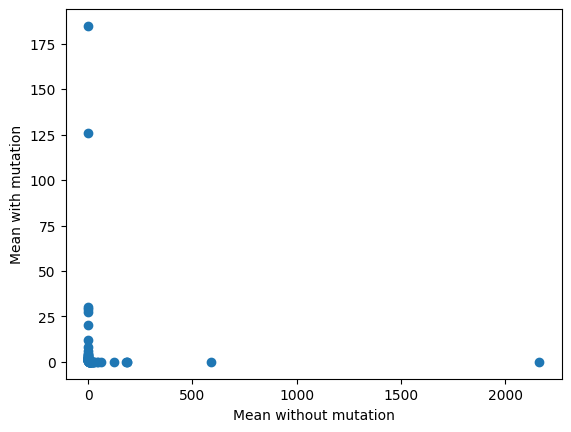

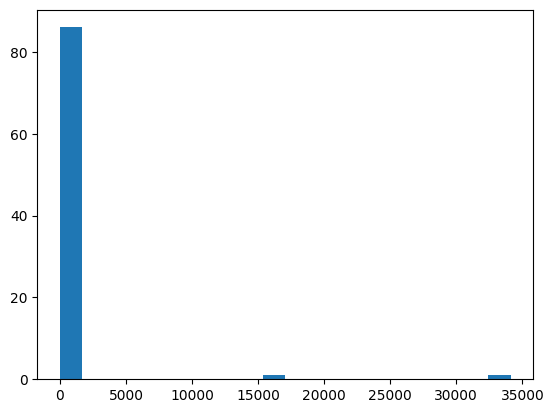

In [ ]:
all_ds = ["pard3", "lov", "gfp", "pte", "gcn4", "nmt"]


for dataset in all_ds:
    across_datasets_results[dataset] = {}
    across_models_results = {}

    dataset_path = DATASET_PATHS[dataset]
    df = pd.read_csv(dataset_path)
    wt_seq = df[df["num_muts"] == 0]["full_seq"].iloc[0]

    # get one-hot encoding for relevant columns
    relevant_columns = get_relevant_columns(dataset, df)
    ohe = get_one_hot_encoding(df, relevant_columns)
    ohe_columns = ohe.columns
    ohe = ohe.to_numpy().astype(int)
    assert ohe.shape[1] == sum([len(pd.unique(df[C])) for C in relevant_columns])

    activity_col = datasets_and_activity[dataset]["activity_col"]
    activity = df[activity_col].to_numpy()
    if dataset == "gfp":
        activity = (~activity).astype(int)

    mean_with_mutation_per_column = []
    mean_without_mutation_per_column = []
    for i in range(ohe.shape[1]):
        mean_val_with_mutation = np.mean(activity[np.where(ohe[:, i] == 1)[0]])
        mean_val_without_mutation = np.mean(activity[np.where(ohe[:, i] == 0)[0]])
        mean_with_mutation_per_column.append(mean_val_with_mutation/mean_val_without_mutation)
        mean_without_mutation_per_column.append(mean_val_without_mutation/mean_val_with_mutation)


    plt.scatter(mean_without_mutation_per_column, mean_with_mutation_per_column)
    plt.xlabel("Mean without mutation")
    plt.ylabel("Mean with mutation")
    plt.show()

    plt.hist(np.array(mean_with_mutation_per_column)/np.array(mean_without_mutation_per_column), bins=20)

    pssm = pd.read_csv(f"./data/{dataset}//pssm_scores.csv")
    ratio = np.array(mean_with_mutation_per_column)/np.array(mean_without_mutation_per_column)

    worst_four = np.argsort(ratio)[0:5]
    best_four = np.argsort(-ratio)[0:5]
    best_four = ohe_columns[best_four]
    worst_four = ohe_columns[worst_four]

    pos_per_best = [int(a.split("_")[0][1:]) for a in best_four.to_list()]
    pos_per_worst = [int(a.split("_")[0][1:]) for a in worst_four.to_list()]
    vocab_per_best = [a.split("_")[-1] for a in best_four.to_list()]
    vocab_per_worst = [a.split("_")[-1] for a in worst_four.to_list()]

    pssm_scores_best = []
    pssm_scores_worst = []
    for p,v in zip(pos_per_best, vocab_per_best):
        pssm_scores_best.append(pssm[pssm["position"] == p][v].iloc[0])

    for p,v in zip(pos_per_worst, vocab_per_worst):
        pssm_scores_worst.append(pssm[pssm["position"] == p][v].iloc[0])

    # PSSM ranks
    ranks_best, ranks_worst = get_best_worst_ranks(pssm_scores_best, pssm_scores_worst)
    print("PSSM average best rank:", np.mean(ranks_best))
    print("PSSM average worst rank:", np.mean(ranks_worst))

    across_model_results["pssm"] = {
        "ranks_best": ranks_best,
        "ranks_worst": ranks_worst,
        "pssm_scores_best": pssm_scores_best,
        "pssm_scores_worst": pssm_scores_worst
    }


In [449]:
sample_region = False

if sample_region:

    K1_dict = {
        "gcn4": 5,
        "lov": 5,
        "gfp": 5,
        "nmt": 5,
        "pte": 5,
        "pard3": 5
    }

    K2_dict = {
        "gcn4": {"best": 5, "worst": 2},
        "lov": {"best": 5, "worst": 4},
        "gfp": {"best": 3, "worst": 6},
        "nmt": {"best": 12, "worst": 1},
        "pte": {"best": 1, "worst": 1},
        "pard3": {"best": 2, "worst": 1}
    }

    worst_four = np.argsort(ratio)[0:K1_dict[dataset]]
    best_four = np.argsort(-ratio)[0:K1_dict[dataset]]

    from_best = np.array(ohe[:, best_four].sum(axis=1) >= K2_dict[dataset]["best"])
    from_worst = np.array(ohe[:, worst_four].sum(axis=1) >= K2_dict[dataset]["worst"])
    print(sum(from_best))
    print(sum(from_worst))
    from_best_activities = []
    from_worst_activities = []
    for _ in range(20):
        best_indices = np.where(from_best)[0]
        worst_indices = np.where(from_worst)[0]

        if len(best_indices) >= 30:
            sampled_best = np.random.choice(best_indices, 30, replace=False)
        else:
            sampled_best = np.random.choice(best_indices, 30, replace=True)
        if len(worst_indices) >= 30:
            sampled_worst = np.random.choice(worst_indices, 30, replace=False)
        else:
            sampled_worst = np.random.choice(worst_indices, 30, replace=True)

        mean_best = np.mean(activity[sampled_best])
        mean_worst = np.mean(activity[sampled_worst])

        from_best_activities.append(mean_best)
        from_worst_activities.append(mean_worst)

    print("Mean activity for from_best, 20 runs: %.3f", np.mean(from_best_activities))
    print("Mean activity for from_worst, 20 runs: %.3f", np.mean(from_worst_activities))

In [451]:

model_to_use = "esm2_t6_8M_UR50D"
logits_path = f"./data/{dataset}/%s_logits.np.npy" % model_to_use
model = plmEmbeddingModel(plm_name="%s" % model_to_use, logits_only=True, emb_only=False).eval()

In [ ]:

if os.path.exists(logits_path):
    logits = np.load(logits_path)
else:
    vocab = model.vocab
    all_tokens = model.encode("".join(vocab))
    wt_tokens = model.encode(wt_seq)
    all_tokens = all_tokens[1:-1]
    logits = model(torch.tensor(wt_tokens).unsqueeze(0))
    logits = logits[0].softmax(dim=1)
    logits = logits.detach().numpy()
    np.save(logits_path, logits)

model_logits = logits
plm_vocab_dict = dict(zip(vocab, all_tokens))
plm_scores_best = []
plm_scores_worst = []

for p,v in zip(pos_per_best, vocab_per_best):
    plm_scores_best.append(model_logits[p, plm_vocab_dict[v]].item())

for p,v in zip(pos_per_worst, vocab_per_worst):
    plm_scores_worst.append(model_logits[p, plm_vocab_dict[v]].item())

rearranged_to_pssm_logits = []

In [456]:
model_logits.shape

(274, 33)

A - 5
R - 10
N - 17
D - 13
C - 23
Q - 16
E - 9
G - 6
H - 21
I - 12
L - 4
K - 15
M - 20
F - 18
P - 14
S - 8
T - 11
W - 22
Y - 19
V - 7


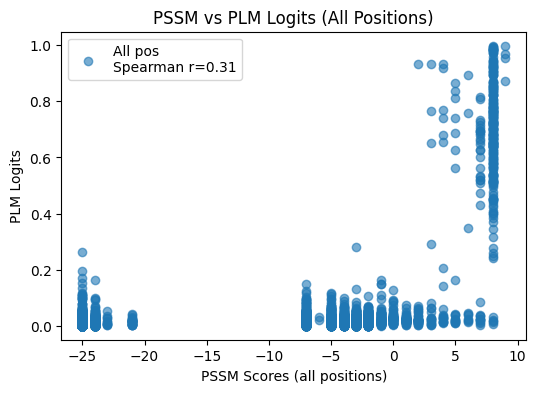

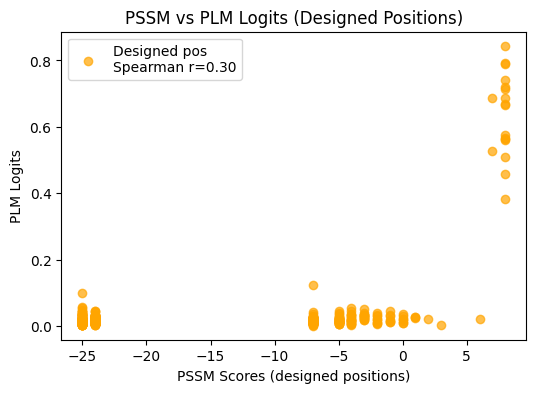

PLM average best rank: 4.2
PLM average worst rank: 6.8


In [ ]:

rearranged_to_pssm_logits = []
for vc in pssm.columns[1:]:
    print("%s - %d" % (p, (np.where(np.array(vocab) == p))[0]))
    rearranged_to_pssm_logits.append(model_logits[1:-1,np.where(np.array(vocab) == vc)[0]])


model_like_pssm = np.concatenate(rearranged_to_pssm_logits, axis=1)


designed_pos = np.unique([int(a.split("_")[0][1:]) for a in ohe_columns.to_list()])
assert pssm.iloc[:,1:].to_numpy().shape == model_like_pssm.shape
from scipy.stats import spearmanr


numeric_pssm = pssm.iloc[:,1:].to_numpy()
softmax = False
if softmax:
    working_pssm = torch.from_numpy(numeric_pssm).to(dtype=torch.float32).softmax(dim=1).numpy()
else:
    working_pssm = numeric_pssm
# Calculate Spearman correlation for all positions
x_all = working_pssm.flatten()
y_all = model_like_pssm.flatten()
spearman_all, pval_all = spearmanr(x_all, y_all)

plt.figure(figsize=(6,4))
plt.scatter(x_all, y_all, label=f"All pos\nSpearman r={spearman_all:.2f}", alpha=0.6)
plt.xlabel('PSSM Scores (all positions)')
plt.ylabel('PLM Logits')
plt.legend()
plt.title('PSSM vs PLM Logits (All Positions)')
plt.show()

# Calculate Spearman correlation for designed positions subset
x_subset = working_pssm[designed_pos - 1,:].flatten()
y_subset = model_like_pssm[designed_pos - 1,:].flatten()
spearman_subset, pval_subset = spearmanr(x_subset, y_subset)

plt.figure(figsize=(6,4))
plt.scatter(x_subset, y_subset, label=f"Designed pos\nSpearman r={spearman_subset:.2f}", color='orange', alpha=0.7)
plt.xlabel('PSSM Scores (designed positions)')
plt.ylabel('PLM Logits')
plt.legend()
plt.title('PSSM vs PLM Logits (Designed Positions)')
plt.show()


cumulative_results[dataset]["rank_results"]["pssm_rank_best"] = ranks_best
cumulative_results[dataset]["rank_results"]["pssm_rank_worst"] = ranks_worst
# PLM ranks
ranks_best, ranks_worst = get_best_worst_ranks(plm_scores_best, plm_scores_worst)

print("PLM average best rank:", np.mean(ranks_best))
print("PLM average worst rank:", np.mean(ranks_worst))


cumulative_results[dataset]["rank_results"]["plm_rank_best"] = ranks_best
cumulative_results[dataset]["rank_results"]["plm_rank_worst"] = ranks_worst



all_ohe_pos_per = [int(a.split("_")[0][1:]) for a in ohe_columns.to_list()]
all_ohe_vocab_per = [a.split("_")[-1] for a in ohe_columns.to_list()]


plm_scores_per_single_mutation_all = []
pssm_scores_per_single_mutation_all = []
for p,v in zip(all_ohe_pos_per, all_ohe_vocab_per):
    plm_scores_per_single_mutation_all.append(model_logits[p, plm_vocab_dict[v]].item())
    pssm_scores_per_single_mutation_all.append(pssm[pssm["position"] == p][v].iloc[0])




space_sizes = sample_settings[dataset]["space_sizes"]
k_values = sample_settings[dataset]["k_values"]

# Prepare dictionaries to store matrices for each space_size
pssm_gof_matrix_dict = {}
pssm_mean_matrix_dict = {}
plm_gof_matrix_dict = {}
plm_mean_matrix_dict = {}

upper_percentile = np.percentile(activity, 90)

pssm_gof_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=int)
pssm_mean_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)
plm_gof_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=int)
plm_mean_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)

pssm_rank = np.argsort(-np.array(pssm_scores_per_single_mutation_all))
plm_rank = np.argsort(-np.array(plm_scores_per_single_mutation_all))

# For each setting of top N unique mutations (per space_size)
for s_idx,s in enumerate(space_sizes):
    # --- PSSM ---
    pssm_first_unique_indices = []
    seen = set()
    arr = np.array(all_ohe_pos_per)[pssm_rank]
    for idx, val in enumerate(arr):
        if val not in seen:
            pssm_first_unique_indices.append(idx)
            seen.add(val)
        if len(pssm_first_unique_indices) == s + 1:
            break
    #chosen_mutations_pssm = pssm_rank[pssm_first_unique_indices]
    chosen_mutations_pssm = pssm_rank[:s+1]

    # --- PLM ---
    plm_first_unique_indices = []
    seen = set()
    arr = np.array(all_ohe_pos_per)[plm_rank]
    for idx, val in enumerate(arr):
        if val not in seen:
            plm_first_unique_indices.append(idx)
            seen.add(val)
        if len(plm_first_unique_indices) == s + 1:
            break
    #chosen_mutations_plm = plm_rank[plm_first_unique_indices]
    chosen_mutations_plm = plm_rank[:s+1]

    # Select N unique mutation columns, score each sequence by sum of their OHE columns
    closest_to_pssm_space = np.argsort(-ohe[:, chosen_mutations_pssm].sum(axis=1))
    closest_to_plm_space = np.argsort(-ohe[:, chosen_mutations_plm].sum(axis=1))

    # For each top-K
    for k_idx, k in enumerate(k_values):
        activities_pssm = activity[closest_to_pssm_space[:k]]
        activities_plm = activity[closest_to_plm_space[:k]]
        # Number of GOF (above upper 90th percentile)
        pssm_gof = np.sum(activities_pssm > upper_percentile)
        plm_gof = np.sum(activities_plm > upper_percentile)
        # Mean activity
        pssm_mean = np.mean(activities_pssm)
        plm_mean = np.mean(activities_plm)

        pssm_gof_matrix[s_idx, k_idx] = pssm_gof
        plm_gof_matrix[s_idx, k_idx] = plm_gof
        pssm_mean_matrix[s_idx, k_idx] = pssm_mean
        plm_mean_matrix[s_idx, k_idx] = plm_mean

cumulative_results[dataset]["design_results"]["pssm_gof_matrix"] = pssm_gof_matrix
cumulative_results[dataset]["design_results"]["plm_gof_matrix"] = plm_gof_matrix
cumulative_results[dataset]["design_results"]["pssm_mean_matrix"] = pssm_mean_matrix
cumulative_results[dataset]["design_results"]["plm_mean_matrix"] = plm_mean_matrix



# Now you have these results for each space_size:
#   - pssm_gof_matrix_dict[space_size]      (GOF counts)
#   - pssm_mean_matrix_dict[space_size]     (mean activities)
#   - plm_gof_matrix_dict[space_size]       (GOF counts)
#   - plm_mean_matrix_dict[space_size]      (mean activities)


In [ ]:

all_ohe_pos_per = [int(a.split("_")[0][1:]) for a in ohe_columns.to_list()]
all_ohe_vocab_per = [a.split("_")[-1] for a in ohe_columns.to_list()]


plm_scores_per_single_mutation_all = []
pssm_scores_per_single_mutation_all = []
for p,v in zip(all_ohe_pos_per, all_ohe_vocab_per):
    plm_scores_per_single_mutation_all.append(model_logits[p, plm_vocab_dict[v]].item())
    pssm_scores_per_single_mutation_all.append(pssm[pssm["position"] == p][v].iloc[0])




space_sizes = sample_settings[dataset]["space_sizes"]
k_values = sample_settings[dataset]["k_values"]

# Prepare dictionaries to store matrices for each space_size
pssm_gof_matrix_dict = {}
pssm_mean_matrix_dict = {}
plm_gof_matrix_dict = {}
plm_mean_matrix_dict = {}

upper_percentile = np.percentile(activity, 90)

pssm_gof_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=int)
pssm_mean_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)
plm_gof_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=int)
plm_mean_matrix = np.zeros((len(space_sizes), len(k_values)), dtype=float)

pssm_rank = np.argsort(-np.array(pssm_scores_per_single_mutation_all))
plm_rank = np.argsort(-np.array(plm_scores_per_single_mutation_all))

# For each setting of top N unique mutations (per space_size)
for s_idx,s in enumerate(space_sizes):
    # --- PSSM ---
    pssm_first_unique_indices = []
    seen = set()
    arr = np.array(all_ohe_pos_per)[pssm_rank]
    for idx, val in enumerate(arr):
        if val not in seen:
            pssm_first_unique_indices.append(idx)
            seen.add(val)
        if len(pssm_first_unique_indices) == s + 1:
            break
    #chosen_mutations_pssm = pssm_rank[pssm_first_unique_indices]
    chosen_mutations_pssm = pssm_rank[:s+1]

    # --- PLM ---
    plm_first_unique_indices = []
    seen = set()
    arr = np.array(all_ohe_pos_per)[plm_rank]
    for idx, val in enumerate(arr):
        if val not in seen:
            plm_first_unique_indices.append(idx)
            seen.add(val)
        if len(plm_first_unique_indices) == s + 1:
            break
    #chosen_mutations_plm = plm_rank[plm_first_unique_indices]
    chosen_mutations_plm = plm_rank[:s+1]

    # Select N unique mutation columns, score each sequence by sum of their OHE columns
    closest_to_pssm_space = np.argsort(-ohe[:, chosen_mutations_pssm].sum(axis=1))
    closest_to_plm_space = np.argsort(-ohe[:, chosen_mutations_plm].sum(axis=1))

    # For each top-K
    for k_idx, k in enumerate(k_values):
        activities_pssm = activity[closest_to_pssm_space[:k]]
        activities_plm = activity[closest_to_plm_space[:k]]
        # Number of GOF (above upper 90th percentile)
        pssm_gof = np.sum(activities_pssm > upper_percentile)
        plm_gof = np.sum(activities_plm > upper_percentile)
        # Mean activity
        pssm_mean = np.mean(activities_pssm)
        plm_mean = np.mean(activities_plm)

        pssm_gof_matrix[s_idx, k_idx] = pssm_gof
        plm_gof_matrix[s_idx, k_idx] = plm_gof
        pssm_mean_matrix[s_idx, k_idx] = pssm_mean
        plm_mean_matrix[s_idx, k_idx] = plm_mean

cumulative_results[dataset]["design_results"]["pssm_gof_matrix"] = pssm_gof_matrix
cumulative_results[dataset]["design_results"]["plm_gof_matrix"] = plm_gof_matrix
cumulative_results[dataset]["design_results"]["pssm_mean_matrix"] = pssm_mean_matrix
cumulative_results[dataset]["design_results"]["plm_mean_matrix"] = plm_mean_matrix



# Now you have these results for each space_size:
#   - pssm_gof_matrix_dict[space_size]      (GOF counts)
#   - pssm_mean_matrix_dict[space_size]     (mean activities)
#   - plm_gof_matrix_dict[space_size]       (GOF counts)
#   - plm_mean_matrix_dict[space_size]      (mean activities)

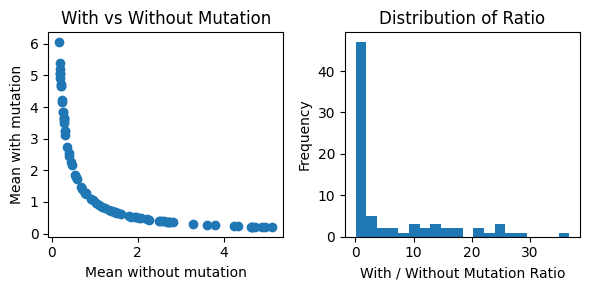

KeyboardInterrupt: 

In [473]:
vocab_col_idx_dict

{0: 'A',
 1: 'R',
 2: 'N',
 3: 'D',
 4: 'C',
 5: 'Q',
 6: 'E',
 7: 'G',
 8: 'H',
 9: 'I',
 10: 'L',
 11: 'K',
 12: 'M',
 13: 'F',
 14: 'P',
 15: 'S',
 16: 'T',
 17: 'W',
 18: 'Y',
 19: 'V'}

array([[-25, -25, -25, ..., -25, -25,  -2],
       [ -5,  -7, -25, ..., -25, -25,  -5],
       [ -4,  -7,  -3, ..., -25,  -7,  -4],
       ...,
       [ -3,  -3,  -3, ...,  -3,  -3,  -3],
       [ -3,  -3,  -3, ...,  -3,  -3,  -3],
       [ -3,  -3,  -3, ...,  -3,  -3,  -3]])

In [ ]:


if dataset not in cumulative_results:
    cumulative_results[dataset] = {}
    cumulative_results[dataset]["rank_results"] = {}
    cumulative_results[dataset]["design_results"] = {}



PSSM average best rank: 3.2
PSSM average worst rank: 7.8
PLM average best rank: 4.2
PLM average worst rank: 6.8


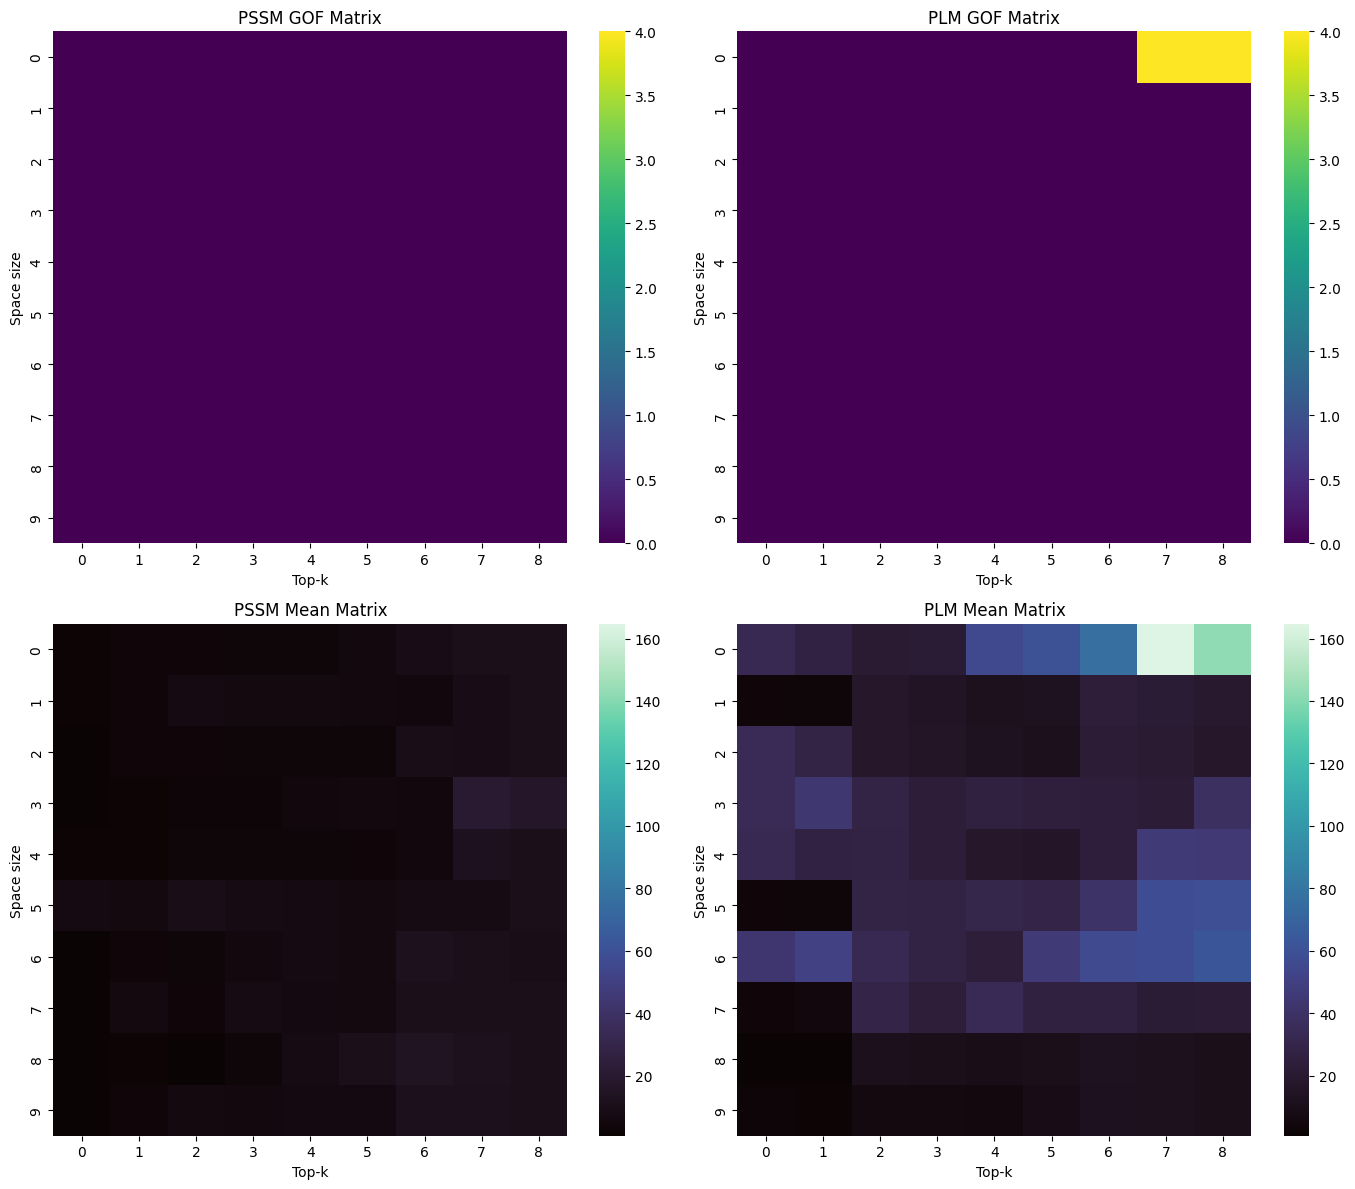

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Determine vmin/vmax for consistent color scaling
gof_min = min(np.min(pssm_gof_matrix), np.min(plm_gof_matrix))
gof_max = max(np.max(pssm_gof_matrix), np.max(plm_gof_matrix))
mean_min = min(np.min(pssm_mean_matrix), np.min(plm_mean_matrix))
mean_max = max(np.max(pssm_mean_matrix), np.max(plm_mean_matrix))

sns.heatmap(pssm_gof_matrix, ax=axes[0,0], vmin=gof_min, vmax=gof_max, cmap="viridis")
axes[0,0].set_title("PSSM GOF Matrix")

sns.heatmap(plm_gof_matrix, ax=axes[0,1], vmin=gof_min, vmax=gof_max, cmap="viridis")
axes[0,1].set_title("PLM GOF Matrix")

sns.heatmap(pssm_mean_matrix, ax=axes[1,0], vmin=mean_min, vmax=mean_max, cmap="mako")
axes[1,0].set_title("PSSM Mean Matrix")

sns.heatmap(plm_mean_matrix, ax=axes[1,1], vmin=mean_min, vmax=mean_max, cmap="mako")
axes[1,1].set_title("PLM Mean Matrix")

for ax in axes.flat:
    ax.set_xlabel("Top-k")
    ax.set_ylabel("Space size")

plt.tight_layout()
plt.show()


if model_to_use not in across_models_results:
    across_models_results[model_to_use] = {}

across_models_results[model_to_use] = cumulative_results



/tmp/ipykernel_173974/750464554.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


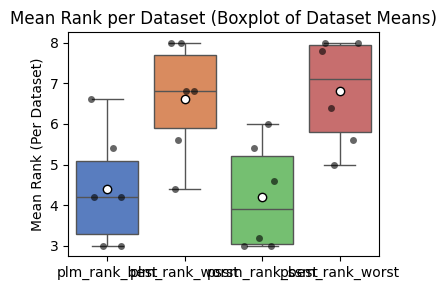

/tmp/ipykernel_173974/750464554.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


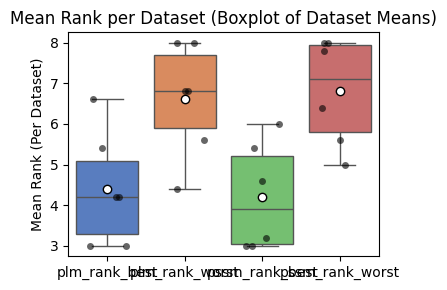

/tmp/ipykernel_173974/750464554.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


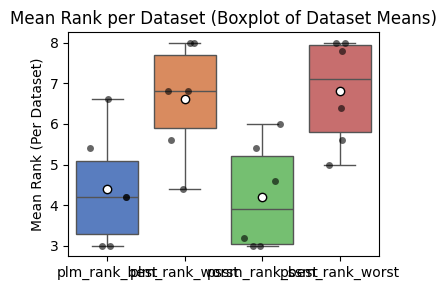

/tmp/ipykernel_173974/750464554.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


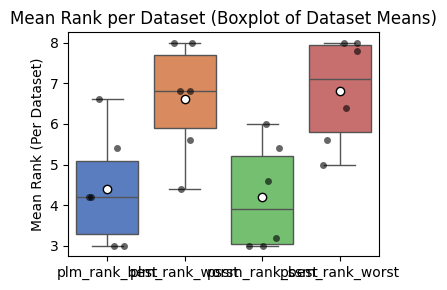

In [ ]:

for k in across_models_results.keys():
    
    cumulative_results = across_models_results[k]
    # Aggregate rank results for all datasets, same as before
    rank_results_list = []

    for dataset, res in cumulative_results.items():
        r = res["rank_results"]
        n_items = len(r["plm_rank_best"])
        for i in range(n_items):
            rank_results_list.append({
                "dataset": dataset,
                "sample_idx": i,
                "plm_rank_best": r["plm_rank_best"][i],
                "plm_rank_worst": r["plm_rank_worst"][i],
                "pssm_rank_best": r["pssm_rank_best"][i],
                "pssm_rank_worst": r["pssm_rank_worst"][i],
            })

    rank_results_df = pd.DataFrame(rank_results_list)

    # Compute mean for each metric per dataset
    mean_df = rank_results_df.groupby("dataset")[["plm_rank_best", "plm_rank_worst", "pssm_rank_best", "pssm_rank_worst"]].mean().reset_index()

    # Grouped barplot: 4 bars (the metrics) for each dataset
    metrics = ["plm_rank_best", "plm_rank_worst", "pssm_rank_best", "pssm_rank_worst"]


    # Compute mean-per-dataset for each metric, put in a "long" dataframe (dataset, metric, mean_rank)
    mean_ranks_list = []
    for dataset, group in rank_results_df.groupby("dataset"):
        for metric in metrics:
            mean_rank = group[metric].mean()
            mean_ranks_list.append({
                "dataset": dataset,
                "Metric": metric,
                "MeanRank": mean_rank,
            })

    mean_ranks_df = pd.DataFrame(mean_ranks_list)

    fig2, ax2 = plt.subplots(figsize=(4, 3))

    # Boxplot the per-dataset means (N=number of datasets points per metric)
    sns.boxplot(
        data=mean_ranks_df,
        x="Metric",
        y="MeanRank",
        ax=ax2,
        showmeans=True,
        meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black"},
        palette="muted",
        fliersize=0
    )
    # Overlay individual per-dataset points (each dataset a point for each metric)
    sns.stripplot(
        data=mean_ranks_df,
        x="Metric",
        y="MeanRank",
        ax=ax2,
        color="k",
        alpha=0.6,
        size=5,
        jitter=0.25,
        dodge=False
    )

    ax2.set_title("Mean Rank per Dataset (Boxplot of Dataset Means)")
    ax2.set_ylabel("Mean Rank (Per Dataset)")
    ax2.set_xlabel("")

    plt.tight_layout()
    plt.show()


In [ ]:
#across_models_results["esm2_t30_8M_UR50D"]
across_models_results["esm2_t6_8M_UR50D"]

{'pard3': {'rank_results': {'pssm_rank_best': array([4.5, 2.5, 4.5, 2.5, 1. ]),
   'pssm_rank_worst': array([ 6.5,  6.5,  8.5,  8.5, 10. ]),
   'plm_rank_best': array([4., 3., 1., 5., 2.]),
   'plm_rank_worst': array([ 7., 10.,  9.,  8.,  6.])},
  'design_results': {'pssm_gof_matrix': array([[ 4,  6, 13, 26, 49],
          [ 2,  4,  8, 21, 49],
          [ 3,  5, 10, 25, 59],
          [ 4,  6, 12, 32, 60],
          [ 4,  7, 13, 34, 74],
          [ 3,  7, 11, 28, 72],
          [ 2,  6, 11, 28, 71],
          [ 5,  9, 14, 34, 68],
          [ 5,  9, 13, 31, 67]]),
   'plm_gof_matrix': array([[ 3,  7,  8, 19, 46],
          [ 4,  8, 15, 39, 78],
          [ 4,  6, 16, 36, 52],
          [ 4,  8, 13, 30, 58],
          [ 2,  6, 11, 24, 55],
          [ 5,  7, 11, 19, 58],
          [ 1,  5, 13, 35, 66],
          [ 1,  4, 13, 31, 66],
          [ 3,  8, 10, 21, 54]]),
   'pssm_mean_matrix': array([[0.84130432, 0.80399854, 0.84892405, 0.75281367, 0.70049219],
          [0.64487878, 0.60